In [29]:
from backend.utils.gmsh_function import *
from backend.src.radiation_algorithm.radiation_algorithm import *
from backend.utils.file_path import *
from backend.rwg.rwg6 import plot_surface_current_distribution

from backend.efield.efield1 import *
from backend.efield.efield2 import *
from backend.efield.efield3 import *

In [30]:
name = "strip_gap_radiation"
path = setup_save_file_paths(name)

In [31]:
mm = 1e-3
width = 20  * mm
length = 2000 * mm
# feed_point = np.array([0, length / 5, 0])
feed_point = np.array([0, 0, 0])

feed_point.shape

(3,)

In [32]:
light_speed = 3e8

frequency = 75e6
wavelength = light_speed / frequency
print(f"wavelength = {wavelength} Meter")

initial_mesh_size = 0.1

wavelength = 4.0 Meter


In [33]:
# initial_mesh_size = wavelength / 30
print(f"initial_mesh_size = {initial_mesh_size}")

gmsh.initialize()
model_name  = "strip_antenna"

print(f"Longueur: {width} m, Hauteur: {length} m")

# Model creation
gmsh.model.add(model_name)
setup_performance_config()

strip_antenna = gmsh.model.occ.addRectangle(-width / 2, -length / 2, 0, width, length)

# synchronize after embedding
gmsh.model.occ.synchronize()

generate_and_save_mesh(path, initial_mesh_size)

# gmsh.fltk.run()

gmsh.finalize()

initial_mesh_size = 0.1
Longueur: 0.02 m, Hauteur: 2.0 m
[PERFORMANCE] Gmsh configured to utilize 16 threads.
Geometry file saved in data/gmsh_files/strip_gap_radiation.brep successfully
--- Starting Mesh Optimization (Dim: 2) ---
--- Optimization Complete ---
Mesh file saved in data/gmsh_files/strip_gap_radiation.msh successfully


if new_feed: matrice_z, voltage, current, surface_current_density = radiation_algorithm(path.mat, frequency, feed_point, voltage_amplitude=1, port_type=0)
else: pass

In [34]:
_ = radiation_algorithm(path, frequency, feed_point, excitation_unit_vector='y', gap_width=0.7 * initial_mesh_size)

Number of points: 42
Number of triangles: 40
Number of edges: 39
Total input power P_in = 0.5*Re(V·I*) = 9.534436e-03 W
Port 0: P_in = 9.5344e-03 W  |  Q_in = 4.6805e-03 VAR  |  Z_in = 42.2578+20.7447j Ω


observationPoint = np.array([0, 0, 5])
calculate_electric_magnetic_field_at_point(path, observationPoint)

observationPoint = np.array([5, 0, 0])
calculate_electric_magnetic_field_at_point(path, observationPoint)

In [35]:
print("Calculating radiation intensity distribution over sphere surface...")
radiation_intensity_distribution_over_sphere_surface(path)

Calculating radiation intensity distribution over sphere surface...
Hollow sphere loaded: 5150 points, 10296 triangles.

[Antenna Results]
  Total Radiated Power : 0.009545783346867835 W
  Gain : 1.6520 (2.18 dBi)

[Power Budget]
  P_in  (0.5*Re(V·I*)) = 9.534436e-03 W
  P_rad (sphere integ.) = 9.545783e-03 W
  Raw efficiency       = 100.1190 %
  Port 0: Z_in = 42.2578+20.7447j Ω  |  R_in = 42.2578 Ω
  Total Efficiency     = 100.00 %
Data saved successfully to data/antennas_gain_power/strip_gap_radiation_gain_power.mat


MODE SELECTED: radiation


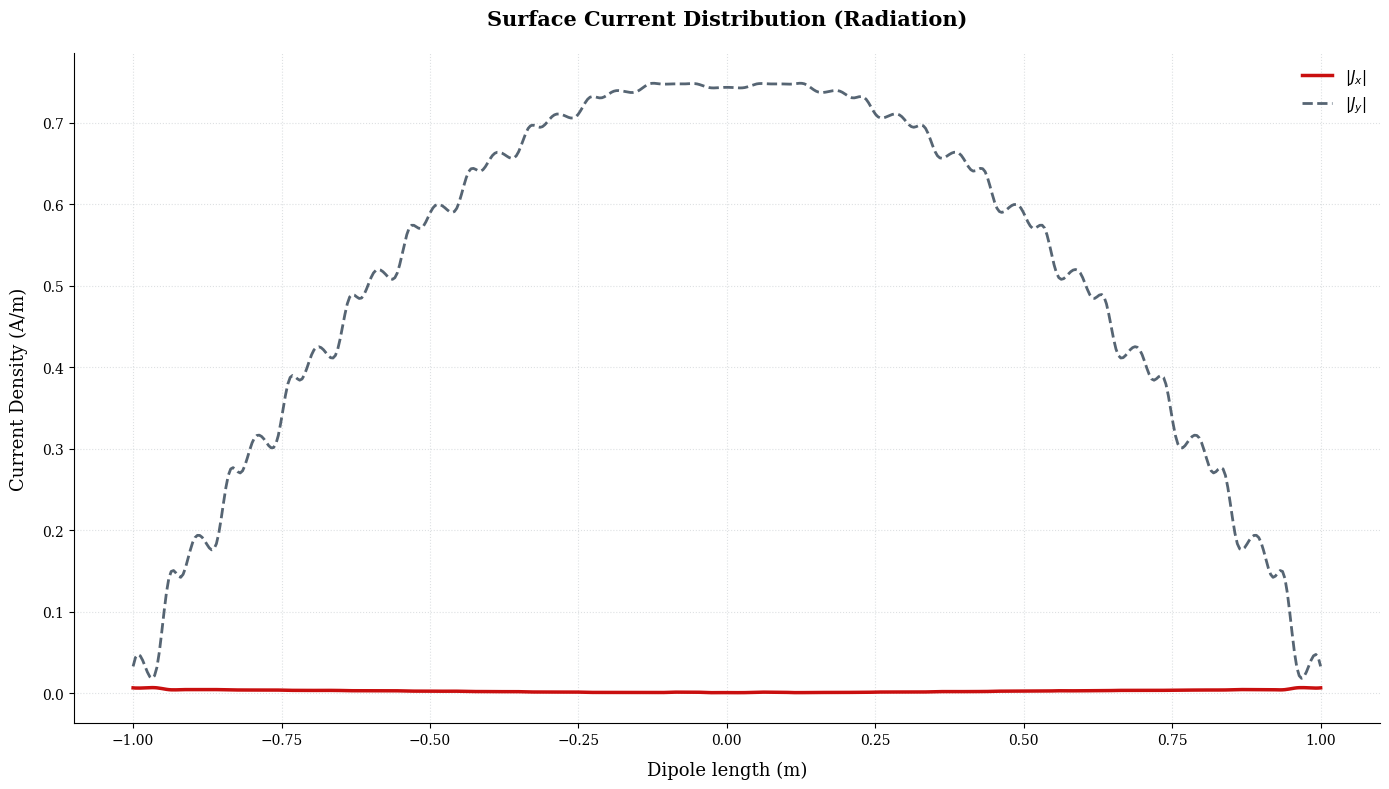

In [36]:
plot_surface_current_distribution(path, mode='radiation')